In [90]:
from google.colab import files
uploaded = files.upload()

In [77]:
# import required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [78]:
df= pd.read_csv('cancer.csv')

In [79]:
df.head()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2


In [80]:
df.describe()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
count,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000,683.000000
mean,4.442167,3.150805,3.215227,2.830161,3.234261,3.544656,3.445095,2.869693,1.603221,2.699854
std,2.820761,3.065145,2.988581,2.864562,2.223085,3.643857,2.449697,3.052666,1.732674,0.954592
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,6.000000,5.000000,5.000000,4.000000,4.000000,6.000000,5.000000,4.000000,1.000000,4.000000
max,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [81]:
cols = df.select_dtypes(include='number').columns

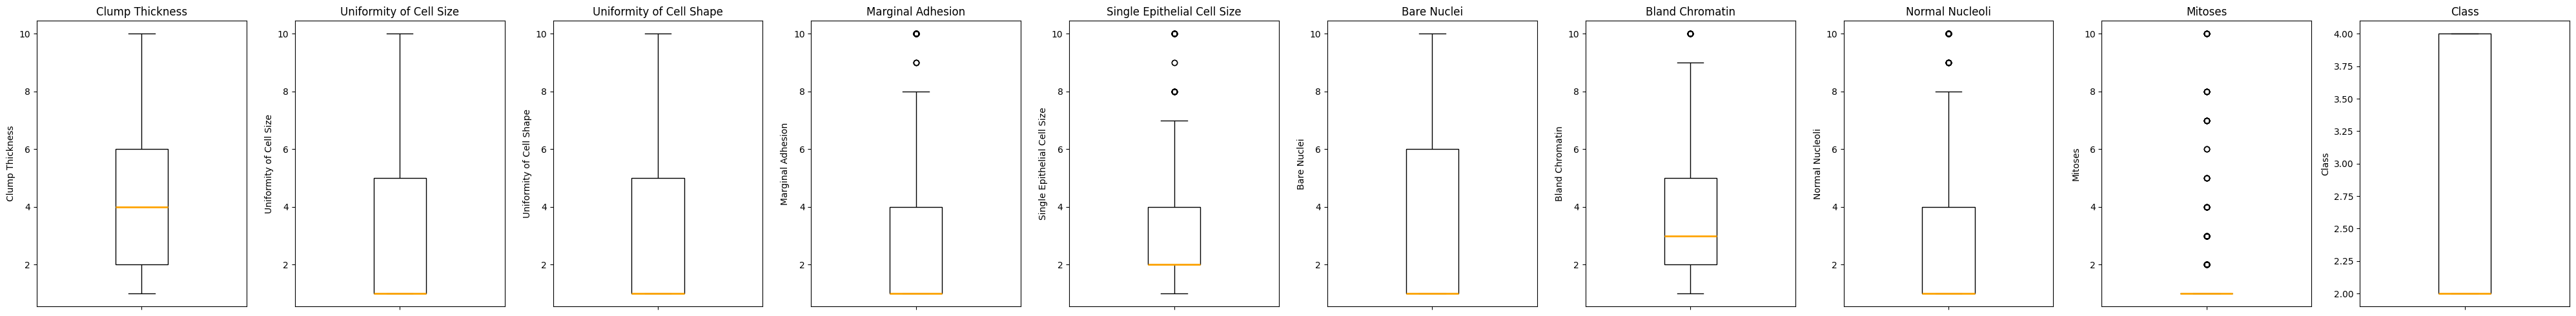

In [82]:
fig, axes = plt.subplots(1, len(df.columns), figsize=(len(df.columns) * 4, 5))
if len(cols) == 1:
  axes = [axes]
else:
  axes= axes.flatten()
for i, col in enumerate(cols):
  sns.boxplot(
      df, y=col,
      ax=axes[i],
      color="white",
      width = 0.25,
      linecolor="black",
      medianprops={"color":"orange", "linewidth":2}
      )
  axes[i].set_title(f'{col}')

plt.tight_layout()
plt.show()


In [83]:
corr = df.select_dtypes(include="number").corr()

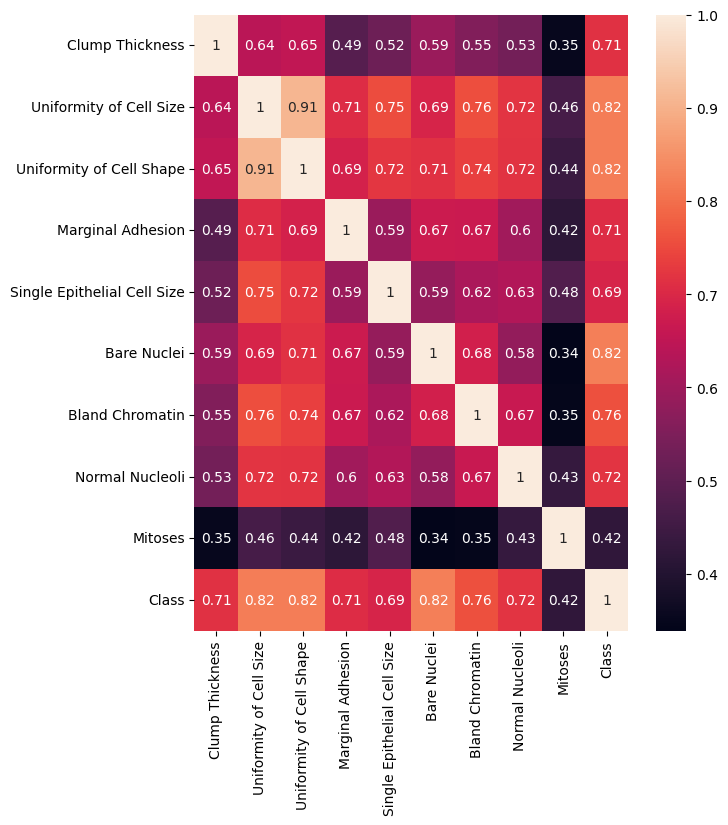

In [84]:
plt.figure(figsize=(7, 8))
sns.heatmap(corr, annot=True)
plt.show()

In [85]:
# Separate features and target variable
X = df.drop(columns='Class')
y = df.Class

In [91]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=72)

# Print the lengths of training and testing sets
print("Training set length:", len(X_train), "\nTesting set length:", len(X_test))
print("Training labels length:", len(y_train), "\nTesting labels length:", len(y_test))

Training set length: 546 
Testing set length: 137
Training labels length: 546 
Testing labels length: 137


In [92]:
# Import LogisticRegression from scikit-learn
from sklearn.linear_model import LogisticRegression

# Create an instance of LogisticRegression
log_reg = LogisticRegression()

# Fit the model on the training data
log_reg.fit(X_train,y_train)

# Make predictions on the testing data
prediction = log_reg.predict(X_test)

# Calculate and print the accuracy score of the model
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, prediction)
print("Accuracy:", accuracy)

Accuracy: 0.9781021897810219


Confusion Matrix:
[[86  2]
 [ 1 48]]


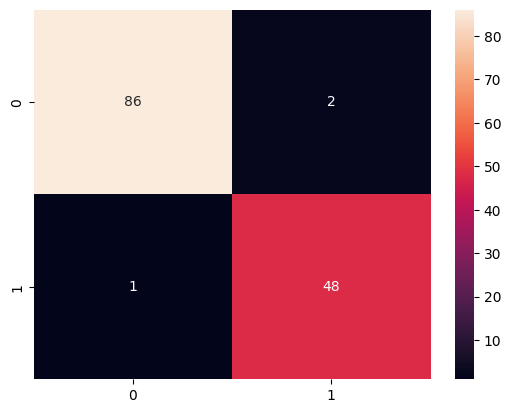

In [93]:
# Import confusion_matrix from scikit-learn
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(y_test, prediction)

# Create a heatmap of the confusion matrix
sns.heatmap(cm, annot=True)

# Print the confusion matrix
print("Confusion Matrix:")
print(cm)